<a href="https://colab.research.google.com/github/cindyjelinsky/miniprojeto_avaliativo_m2_visaocomputacional_sctech/blob/SPRINT-2/mini_projeto_modulo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SPRINT 1 -> Importação do dataset e visualização inicial do conteúdo

In [1]:
from google.colab import drive

import gdown
import os

import zipfile

import random
import cv2
import matplotlib.pyplot as plt

url = "https://drive.google.com/uc?id=1NZOjCHDRrpn7PmbFKVqegUP5arfdXHKK"

gdown.download(url, "/content/dataset.zip", quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1NZOjCHDRrpn7PmbFKVqegUP5arfdXHKK
From (redirected): https://drive.google.com/uc?id=1NZOjCHDRrpn7PmbFKVqegUP5arfdXHKK&confirm=t&uuid=714bd851-4809-456a-8d6d-78163962a62f
To: /content/dataset.zip
100%|██████████| 32.2M/32.2M [00:00<00:00, 84.7MB/s]


'/content/dataset.zip'

In [2]:
print(os.path.exists("/content/dataset.zip"))

True


In [3]:


zip_path = "/content/dataset.zip"
extract_path = "/content/dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

print("Dataset extraído")

dataset_path = "/content/dataset/casting_512x512"

def_path = os.path.join(dataset_path, "def_front")
ok_path = os.path.join(dataset_path, "ok_front")

def_images = os.listdir(def_path)
ok_images = os.listdir(ok_path)

print("Imagens com defeito:", len(def_images))
print("Imagens sem defeito:", len(ok_images))
print("Total de imagens:", len(def_images) + len(ok_images))

Dataset extraído
Imagens com defeito: 781
Imagens sem defeito: 519
Total de imagens: 1300


#SPRINT 2 Grayscale e Suavização de ruídos

Conversão da imagem para escala de cinza utilizando o OpenCV. A imagem original possui três canais de cor,enquanto a imagem em escala de cinza possui apenas um canal.

Gaussian Blur com um kernel de tamanho (5, 5). O filtro realizou uma suavização da imagem, reduzindo pequenas variações de intensidade.


Arquivo: cast_def_0_219.jpeg
Dimensões: (512, 512, 3)
Dimensões da imagem em escala de cinza: (512, 512)


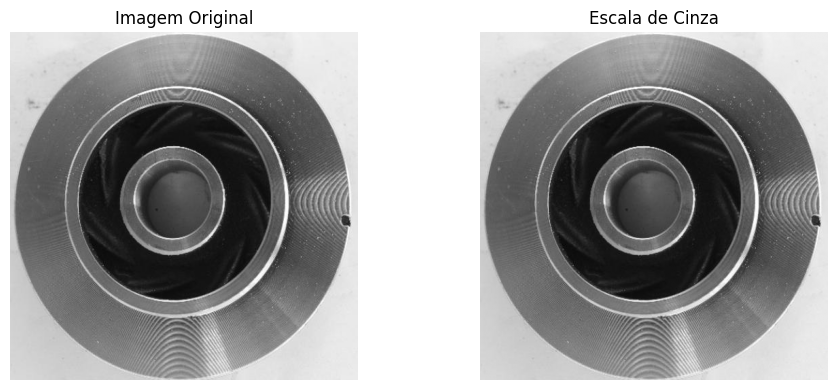

In [11]:
#Greyscale
imagem_nome = random.choice(def_images)
imagem_path = os.path.join(def_path, imagem_nome)

imagem_bgr = cv2.imread(imagem_path)

print("Arquivo:", imagem_nome)
print("Dimensões:", imagem_bgr.shape)

imagem_cinza = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)

print("Dimensões da imagem em escala de cinza:", imagem_cinza.shape)

#Visualizar imagens

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB))
plt.title("Imagem Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagem_cinza, cmap="gray")
plt.title("Escala de Cinza")
plt.axis("off")

plt.tight_layout()
plt.show()

Dimensões após Gaussian Blur: (512, 512)


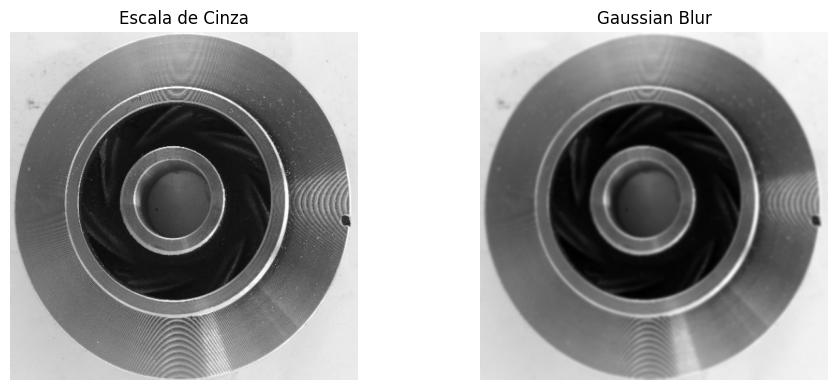

In [15]:
#Gaussian Blur
imagem_blur = cv2.GaussianBlur(imagem_cinza, (9,9), 0)

print("Dimensões após Gaussian Blur:", imagem_blur.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(imagem_cinza, cmap="gray")
plt.title("Escala de Cinza")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagem_blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.tight_layout()
plt.show()

#SPRINT 3